In [1]:
import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from collections import Counter

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

warnings.filterwarnings('ignore')

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0d1117',
    'axes.facecolor'   : '#0d1117',
    'axes.edgecolor'   : '#334155',
    'axes.labelcolor'  : '#94a3b8',
    'xtick.color'      : '#64748b',
    'ytick.color'      : '#64748b',
    'text.color'       : '#e2e8f0',
    'grid.color'       : '#1e293b',
    'grid.linestyle'   : '--',
    'font.family'      : 'monospace',
})

ACCENT  = '#3b82f6'   # blue
ACCENT2 = '#8b5cf6'   # purple
ACCENT3 = '#10b981'   # green

print('✓ Imports complete')

✓ Imports complete


In [2]:
# ── Paths ───────────────────────────────────────────────────────────────────
ROOT_DIR      = Path('..').resolve()            # project root (Sciret2/)
DATA_RAW      = ROOT_DIR / '1_data' / 'raw'
DATA_PROC     = ROOT_DIR / '1_data' / 'processed'
DATA_EMB      = ROOT_DIR / '1_data' / 'embeddings'
CHROMA_DIR    = DATA_EMB / 'chroma_db'

# Create dirs if they don't exist
for d in [DATA_PROC, DATA_EMB, CHROMA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Dataset settings ────────────────────────────────────────────────────────
METADATA_PATH = DATA_RAW / 'metadata.csv'       # CORD-19 metadata file
N_PAPERS      = 1000                             # ← change to 50000 on Kaggle

# ── Chunking settings ───────────────────────────────────────────────────────
# A 'chunk' is a piece of text we embed and store in the vector database.
# Too small = loses context. Too large = retrieval picks up noise.
CHUNK_SIZE    = 400    # target tokens per chunk (≈ 300 words)
CHUNK_OVERLAP = 50     # tokens of overlap between consecutive chunks
                       # overlap ensures sentences at boundaries are not lost

# ── Embedding settings ──────────────────────────────────────────────────────
# BGE-M3 is the current state-of-art free embedding model.
# It outperforms the DPR model used in your 2022 SciRet system.
EMBED_MODEL   = 'BAAI/bge-m3'
EMBED_BATCH   = 16     # how many chunks to embed at once
                       # lower = less RAM. Increase if you have more memory.

# ── Retrieval settings ──────────────────────────────────────────────────────
TOP_K         = 5      # how many results to retrieve per query

print(f'✓ Config set')
print(f'  Root dir  : {ROOT_DIR}')
print(f'  Data raw  : {DATA_RAW}')
print(f'  Papers    : {N_PAPERS:,}')
print(f'  Chunk size: {CHUNK_SIZE} tokens')

✓ Config set
  Root dir  : D:\SciRet-Scientific-Information-Made-Easy\Sciret2
  Data raw  : D:\SciRet-Scientific-Information-Made-Easy\Sciret2\1_data\raw
  Papers    : 1,000
  Chunk size: 400 tokens


In [3]:
print(f'Loading metadata from: {METADATA_PATH}')
df_raw = pd.read_csv(METADATA_PATH, low_memory=False)

print(f'\n── Raw dataset ──────────────────────────────')
print(f'  Total papers : {len(df_raw):,}')
print(f'  Columns      : {list(df_raw.columns)}')
print(f'  Memory usage : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')

df_raw.head(3)

Loading metadata from: D:\SciRet-Scientific-Information-Made-Easy\Sciret2\1_data\raw\metadata.csv

── Raw dataset ──────────────────────────────
  Total papers : 1,056,660
  Columns      : ['cord_uid', 'sha', 'source_x', 'title', 'doi', 'pmcid', 'pubmed_id', 'license', 'abstract', 'publish_time', 'authors', 'journal', 'mag_id', 'who_covidence_id', 'arxiv_id', 'pdf_json_files', 'pmc_json_files', 'url', 's2_id']
  Memory usage : 2919.5 MB


,cord_uid,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,mag_id,who_covidence_id,arxiv_id,pdf_json_files,pmc_json_files,url,s2_id
0,ug7v899j,d1aafb70c066a2068b02786f8929fd9c900897fb,PMC,Clinical features of culture-proven Mycoplasma...,10.1186/1471-2334-1-6,PMC35282,11472636,no-cc,OBJECTIVE: This retrospective chart review des...,2001-07-04,"Madani, Tariq A; Al-Ghamdi, Aisha A",BMC Infect Dis,NaN,NaN,NaN,document_parses/pdf_json/d1aafb70c066a2068b027...,document_parses/pmc_json/PMC35282.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN
1,02tnwd4m,6b0567729c2143a66d737eb0a2f63f2dce2e5a7d,PMC,Nitric oxide: a pro-inflammatory mediator in l...,10.1186/rr14,PMC59543,11667967,no-cc,Inflammatory diseases of the respiratory tract...,2000-08-15,"Vliet, Albert van der; Eiserich, Jason P; Cros...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/6b0567729c2143a66d737...,document_parses/pmc_json/PMC59543.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
2,ejv2xln0,06ced00a5fc04215949aa72528f2eeaae1d58927,PMC,Surfactant protein-D and pulmonary host defense,10.1186/rr19,PMC59549,11667972,no-cc,Surfactant protein-D (SP-D) participates in th...,2000-08-25,"Crouch, Erika C",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/06ced00a5fc04215949aa...,document_parses/pmc_json/PMC59549.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN


In [4]:
print('── Missing values per column ────────────────')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_df = pd.DataFrame({'missing': missing, 'percent': missing_pct})
print(missing_df[missing_df['missing'] > 0].sort_values('percent', ascending=False).to_string())

print(f'\n── Duplicate cord_uid ───────────────────────')
n_dupes = df_raw['cord_uid'].duplicated().sum()
print(f'  Duplicates : {n_dupes:,}')

print(f'\n── Papers with abstract ─────────────────────')
has_abstract = df_raw['abstract'].notna() & (df_raw['abstract'].str.strip() != '')
print(f'  With abstract    : {has_abstract.sum():,} ({has_abstract.mean()*100:.1f}%)')
print(f'  Without abstract : {(~has_abstract).sum():,}')

── Missing values per column ────────────────
                  missing  percent
mag_id            1056660    100.0
arxiv_id          1042411     98.7
pmc_json_files     740918     70.1
sha                682894     64.6
pdf_json_files     682894     64.6
pmcid              667089     63.1
who_covidence_id   573725     54.3
pubmed_id          557728     52.8
doi                399880     37.8
url                369726     35.0
abstract           235544     22.3
journal             87322      8.3
s2_id               80192      7.6
authors             23869      2.3
publish_time         1814      0.2
title                 503      0.0

── Duplicate cord_uid ───────────────────────
  Duplicates : 85,824

── Papers with abstract ─────────────────────
  With abstract    : 821,116 (77.7%)
  Without abstract : 235,544


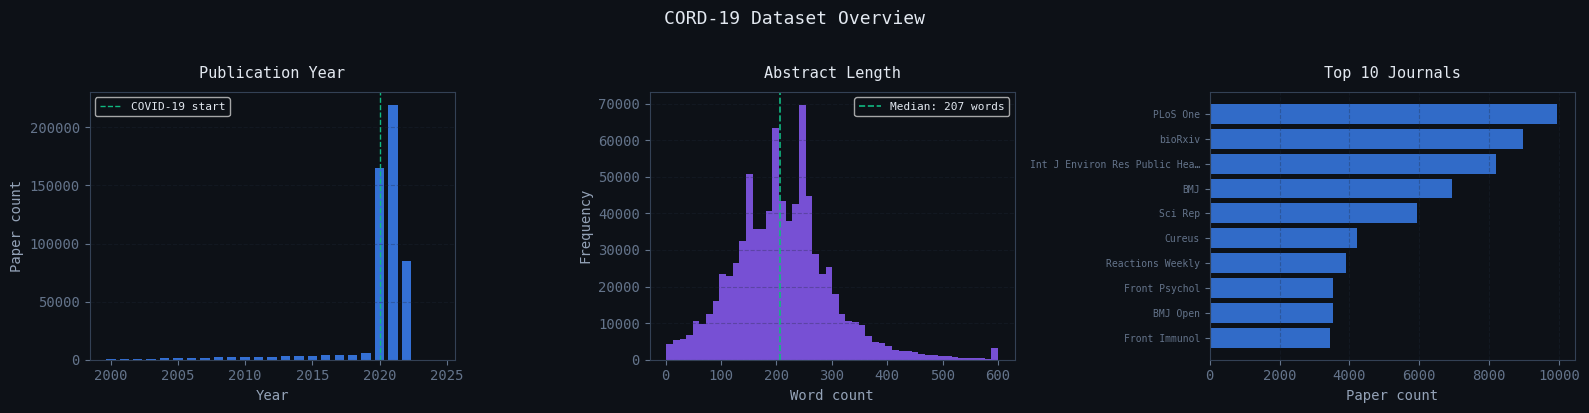

✓ Chart saved to 1_data/processed/dataset_overview.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor('#0d1117')

# ── Chart 1: Publication year ────────────────────────────────────────────
ax1 = axes[0]
if 'publish_time' in df_raw.columns:
    df_raw['year'] = pd.to_datetime(df_raw['publish_time'], errors='coerce').dt.year
    year_counts = df_raw['year'].value_counts().sort_index()
    year_counts = year_counts[(year_counts.index >= 2000) & (year_counts.index <= 2024)]
    ax1.bar(year_counts.index, year_counts.values, color=ACCENT, alpha=0.85, width=0.7)
    ax1.axvline(2020, color=ACCENT3, linestyle='--', linewidth=1, label='COVID-19 start')
    ax1.legend(fontsize=8)
ax1.set_title('Publication Year', fontsize=11, pad=10)
ax1.set_xlabel('Year'); ax1.set_ylabel('Paper count')
ax1.grid(axis='y', alpha=0.3)

# ── Chart 2: Abstract length ─────────────────────────────────────────────
ax2 = axes[1]
abstract_lengths = df_raw['abstract'].dropna().str.split().str.len()
ax2.hist(abstract_lengths.clip(upper=600), bins=50, color=ACCENT2, alpha=0.85, edgecolor='none')
ax2.axvline(abstract_lengths.median(), color=ACCENT3, linestyle='--', linewidth=1.2,
            label=f'Median: {abstract_lengths.median():.0f} words')
ax2.set_title('Abstract Length', fontsize=11, pad=10)
ax2.set_xlabel('Word count'); ax2.set_ylabel('Frequency')
ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)

# ── Chart 3: Top journals ────────────────────────────────────────────────
ax3 = axes[2]
if 'journal' in df_raw.columns:
    top_journals = df_raw['journal'].dropna().value_counts().head(10)
    # shorten names for display
    labels = [j[:28]+'…' if len(j) > 28 else j for j in top_journals.index]
    ax3.barh(range(len(top_journals)), top_journals.values, color=ACCENT, alpha=0.8)
    ax3.set_yticks(range(len(top_journals)))
    ax3.set_yticklabels(labels, fontsize=7)
    ax3.invert_yaxis()
ax3.set_title('Top 10 Journals', fontsize=11, pad=10)
ax3.set_xlabel('Paper count'); ax3.grid(axis='x', alpha=0.3)

plt.suptitle('CORD-19 Dataset Overview', fontsize=13, y=1.02, color='#e2e8f0')
plt.tight_layout()
plt.savefig(DATA_PROC / 'dataset_overview.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('✓ Chart saved to 1_data/processed/dataset_overview.png')

In [6]:
df = df_raw.copy()
initial = len(df)
print(f'Starting with {initial:,} papers')
print('─' * 45)

# 1. Remove duplicates
df = df.drop_duplicates(subset='cord_uid', keep='first')
print(f'After dedup          : {len(df):,} ({initial - len(df):,} removed)')

# 2. Require non-empty abstract
df = df[df['abstract'].notna() & (df['abstract'].str.strip().str.len() > 0)]
print(f'After abstract filter: {len(df):,}')

# 3. Minimum abstract length (50 words)
df = df[df['abstract'].str.split().str.len() >= 50]
print(f'After length filter  : {len(df):,}')

# 4. COVID relevance — keep papers mentioning key terms
COVID_KEYWORDS = [
    'covid', 'coronavirus', 'sars-cov', 'sars cov',
    'pandemic', 'covid-19', 'ncov'
]
pattern = '|'.join(COVID_KEYWORDS)
mask = (
    df['title'].str.lower().str.contains(pattern, na=False) |
    df['abstract'].str.lower().str.contains(pattern, na=False)
)
df = df[mask]
print(f'After COVID filter   : {len(df):,}')

# 5. Select columns we need
KEEP_COLS = ['cord_uid', 'title', 'abstract', 'authors', 'journal', 
             'publish_time', 'url', 'doi']
KEEP_COLS = [c for c in KEEP_COLS if c in df.columns]
df = df[KEEP_COLS].reset_index(drop=True)

# 6. Take our working subset
if len(df) > N_PAPERS:
    # Sample recent papers preferentially — they have more COVID info
    df['year'] = pd.to_datetime(df['publish_time'], errors='coerce').dt.year
    df_recent = df[df['year'] >= 2020]
    df_older  = df[df['year'] <  2020]
    
    n_recent = min(int(N_PAPERS * 0.8), len(df_recent))  # 80% from 2020+
    n_older  = N_PAPERS - n_recent
    
    df = pd.concat([
        df_recent.sample(n=n_recent, random_state=42),
        df_older.sample(n=min(n_older, len(df_older)), random_state=42)
    ]).reset_index(drop=True)

print('─' * 45)
print(f'Final working subset : {len(df):,} papers')
print(f'Columns kept         : {list(df.columns)}')
df.head(3)

Starting with 1,056,660 papers
─────────────────────────────────────────────
After dedup          : 970,836 (85,824 removed)
After abstract filter: 763,499
After length filter  : 742,279
After COVID filter   : 494,692
─────────────────────────────────────────────
Final working subset : 1,000 papers
Columns kept         : ['cord_uid', 'title', 'abstract', 'authors', 'journal', 'publish_time', 'url', 'doi', 'year']


,cord_uid,title,abstract,authors,journal,publish_time,url,doi,year
0,dx2cx9lx,Vitamin D deficiency aggravates COVID-19: syst...,There is still limited evidence regarding the ...,"Pereira, Marcos; Dantas Damascena, Alialdo; Ga...",Critical reviews in food science and nutrition,2020-11-04,https://doi.org/10.1080/10408398.2020.1841090;...,10.1080/10408398.2020.1841090,2020.0
1,iqh5ymsv,Worries about COVID-19 infection and psycholog...,Objective: This study examined the relationshi...,"Uehara, M.; Ishimaru, T.; Ando, H.; Tateishi, ...",NaN,2021-02-19,https://doi.org/10.1101/2021.02.16.21250657; h...,10.1101/2021.02.16.21250657,2021.0
2,itlv2mx1,A global perspective on improving patient care...,BACKGROUND Uncomplicated urinary tract infecti...,"Wagenlehner, Florian; Nicolle, Lindsay; Bartol...",Journal of global antimicrobial resistance,2021-12-08,https://doi.org/10.1016/j.jgar.2021.11.008; ht...,10.1016/j.jgar.2021.11.008,2021.0


In [7]:
# ── Export processed data ───────────────────────────────────
# Materializing the cleaned dataset prevents having to re-run filtering and 
# sampling logic when starting the next notebook or restarting the kernel.

EXPORT_FILENAME = 'cleaned_metadata.csv'
EXPORT_PATH = DATA_PROC / EXPORT_FILENAME

df.to_csv(EXPORT_PATH, index=False)

print(f'✓ Cleaned dataset exported: {EXPORT_PATH}')
print(f'  Records saved: {len(df):,}')
print(f'\\nNext step: Use this file as input for notebooks/02_text_chunking.ipynb')


✓ Cleaned dataset exported: D:\SciRet-Scientific-Information-Made-Easy\Sciret2\1_data\processed\cleaned_metadata.csv
  Records saved: 1,000
\nNext step: Use this file as input for notebooks/02_text_chunking.ipynb


In [8]:
def clean_text(text: str) -> str:
    """
    Clean scientific paper text.
    
    Each step removes a specific type of noise.
    We apply them in order — the output of one feeds into the next.
    """
    if not isinstance(text, str):
        return ''
    
    # Remove citation markers like [1], [2,3], [1-5]
    text = re.sub(r'\[\d+(?:[,–-]\d+)*\]', '', text)
    
    # Remove HTML entities
    text = re.sub(r'&[a-zA-Z]+;', ' ', text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    
    # Remove LaTeX-style commands
    text = re.sub(r'\\[a-zA-Z]+\{[^}]*\}', '', text)
    
    # Normalise whitespace — collapse multiple spaces/tabs/newlines
    text = re.sub(r'[\t\r\n]+', ' ', text)
    text = re.sub(r' {2,}', ' ', text)
    
    # Remove standalone numbers at sentence boundaries (page numbers etc.)
    text = re.sub(r'(?<![\w.])\d{1,3}(?![\w.%°])', '', text)
    
    return text.strip()


# Apply cleaning
df['title_clean']    = df['title'].apply(clean_text)
df['abstract_clean'] = df['abstract'].apply(clean_text)

# Show before/after for one paper
print('── Before / After cleaning example ──────────')
idx = 0
print(f'BEFORE: {df["abstract"].iloc[idx][:300]}')
print()
print(f'AFTER : {df["abstract_clean"].iloc[idx][:300]}')

── Before / After cleaning example ──────────
BEFORE: There is still limited evidence regarding the influence of vitamin D in people with COVID-19. In this systematic review and meta-analysis, we analyze the association between vitamin D deficiency and COVID-19 severity, via an analysis of the prevalence of vitamin D deficiency and insufficiency in peo

AFTER : There is still limited evidence regarding the influence of vitamin D in people with COVID-19. In this systematic review and meta-analysis, we analyze the association between vitamin D deficiency and COVID- severity, via an analysis of the prevalence of vitamin D deficiency and insufficiency in peopl


In [9]:
def estimate_tokens(text: str) -> int:
    """
    Rough token count estimate.
    Rule of thumb: 1 token ≈ 0.75 words for English scientific text.
    We use word count / 0.75 as a fast approximation.
    Real tokenisation requires loading the tokeniser — too slow for exploration.
    """
    return int(len(text.split()) / 0.75)


def chunk_text(text: str, chunk_size: int = 400, overlap: int = 50) -> list:
    """
    Split text into overlapping sentence-boundary chunks.
    
    Algorithm:
    1. Split text into individual sentences using NLTK
    2. Accumulate sentences into a buffer until token budget is full
    3. When full: save the chunk, step back 'overlap' tokens, continue
    4. Repeat until all sentences are processed
    
    Args:
        text       : cleaned input text
        chunk_size : target tokens per chunk
        overlap    : tokens of overlap between chunks
    
    Returns:
        List of text chunks
    """
    if not text or len(text.strip()) < 50:
        return []
    
    sentences   = sent_tokenize(text)
    chunks      = []
    buffer      = []      # current sentences being accumulated
    buffer_toks = 0       # estimated tokens in buffer
    
    for sent in sentences:
        sent_toks = estimate_tokens(sent)
        
        # If a single sentence exceeds chunk_size, include it alone
        if sent_toks > chunk_size:
            if buffer:
                chunks.append(' '.join(buffer))
                buffer, buffer_toks = [], 0
            chunks.append(sent)
            continue
        
        # Adding this sentence would exceed budget — save chunk and start new
        if buffer_toks + sent_toks > chunk_size and buffer:
            chunks.append(' '.join(buffer))
            
            # Overlap: step back until we are within (chunk_size - overlap) tokens
            overlap_toks = 0
            overlap_buf  = []
            for s in reversed(buffer):
                s_toks = estimate_tokens(s)
                if overlap_toks + s_toks > overlap:
                    break
                overlap_buf.insert(0, s)
                overlap_toks += s_toks
            
            buffer      = overlap_buf
            buffer_toks = overlap_toks
        
        buffer.append(sent)
        buffer_toks += sent_toks
    
    # Add the last remaining buffer
    if buffer:
        chunks.append(' '.join(buffer))
    
    return [c.strip() for c in chunks if len(c.strip()) > 30]


# ── Test the chunker on one paper ────────────────────────────────────────
sample_abstract = df['abstract_clean'].iloc[0]
sample_chunks   = chunk_text(sample_abstract, CHUNK_SIZE, CHUNK_OVERLAP)

print(f'── Chunking example ──────────────────────────')
print(f'Input  : {estimate_tokens(sample_abstract):,} tokens')
print(f'Chunks : {len(sample_chunks)}')
print()
for i, c in enumerate(sample_chunks):
    print(f'Chunk {i+1} ({estimate_tokens(c)} tokens):')
    print(f'  {c[:200]}...' if len(c) > 200 else f'  {c}')
    print()

── Chunking example ──────────────────────────
Input  : 262 tokens
Chunks : 1

Chunk 1 (262 tokens):
  There is still limited evidence regarding the influence of vitamin D in people with COVID-19. In this systematic review and meta-analysis, we analyze the association between vitamin D deficiency and C...



In [10]:
records = []

for _, row in tqdm(df.iterrows(), total=len(df), desc='Chunking papers'):
    # Combine title + abstract for richer context
    # In Phase 2 we will also add body text from the JSON files
    full_text = f"{row['title_clean']}. {row['abstract_clean']}"
    chunks    = chunk_text(full_text, CHUNK_SIZE, CHUNK_OVERLAP)
    
    for chunk_idx, chunk in enumerate(chunks):
        records.append({
            'chunk_id'          : f"{row['cord_uid']}_chunk_{chunk_idx:03d}",
            'cord_uid'          : row['cord_uid'],
            'title'             : row['title_clean'],
            'chunk_text'        : chunk,
            'chunk_index'       : chunk_idx,
            'chunk_token_est'   : estimate_tokens(chunk),
            # Prepend title for BGE-M3 — improves embedding quality
            'text_for_embedding': f"Title: {row['title_clean']}. Content: {chunk}",
            'publish_time'      : row.get('publish_time', ''),
            'journal'           : row.get('journal', ''),
            'url'               : row.get('url', ''),
        })

df_chunks = pd.DataFrame(records)

print(f'\n── Chunking complete ────────────────────────')
print(f'  Papers processed : {len(df):,}')
print(f'  Total chunks     : {len(df_chunks):,}')
print(f'  Avg chunks/paper : {len(df_chunks)/len(df):.1f}')
print(f'  Avg chunk tokens : {df_chunks["chunk_token_est"].mean():.0f}')
print(f'  Min chunk tokens : {df_chunks["chunk_token_est"].min()}')
print(f'  Max chunk tokens : {df_chunks["chunk_token_est"].max()}')
df_chunks.head(3)

Chunking papers:   0%|          | 0/1000 [00:00<?, ?it/s]

Chunking papers: 100%|██████████| 1000/1000 [00:00<00:00, 3666.04it/s]


── Chunking complete ────────────────────────
  Papers processed : 1,000
  Total chunks     : 1,166
  Avg chunks/paper : 1.2
  Avg chunk tokens : 268
  Min chunk tokens : 9
  Max chunk tokens : 406


,chunk_id,cord_uid,title,chunk_text,chunk_index,chunk_token_est,text_for_embedding,publish_time,journal,url
0,dx2cx9lx_chunk_000,dx2cx9lx,Vitamin D deficiency aggravates COVID-: system...,Vitamin D deficiency aggravates COVID-: system...,0,274,Title: Vitamin D deficiency aggravates COVID-:...,2020-11-04,Critical reviews in food science and nutrition,https://doi.org/10.1080/10408398.2020.1841090;...
1,iqh5ymsv_chunk_000,iqh5ymsv,Worries about COVID- infection and psychologic...,Worries about COVID- infection and psychologic...,0,369,Title: Worries about COVID- infection and psyc...,2021-02-19,NaN,https://doi.org/10.1101/2021.02.16.21250657; h...
2,itlv2mx1_chunk_000,itlv2mx1,A global perspective on improving patient care...,A global perspective on improving patient care...,0,353,Title: A global perspective on improving patie...,2021-12-08,Journal of global antimicrobial resistance,https://doi.org/10.1016/j.jgar.2021.11.008; ht...


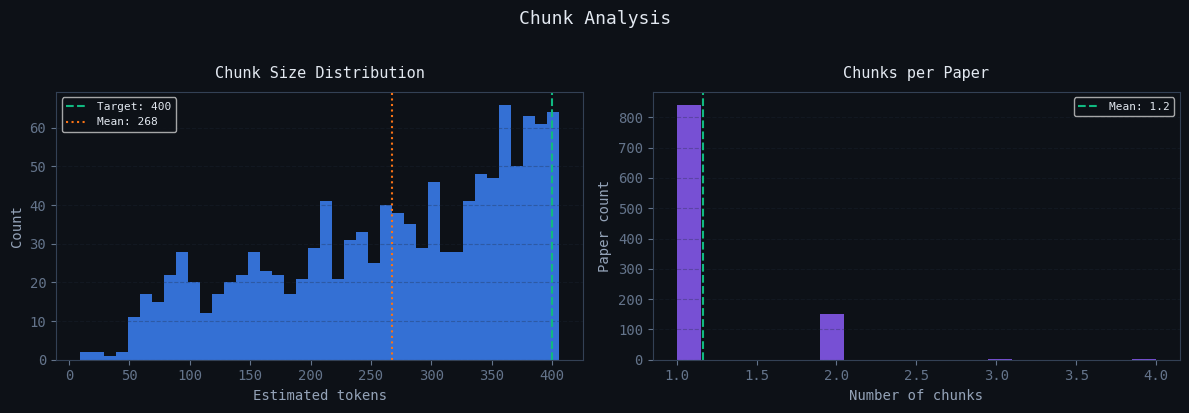

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0d1117')

# Chunk token distribution
ax1 = axes[0]
ax1.hist(df_chunks['chunk_token_est'], bins=40, color=ACCENT, alpha=0.85, edgecolor='none')
ax1.axvline(CHUNK_SIZE, color=ACCENT3, linestyle='--', linewidth=1.5,
            label=f'Target: {CHUNK_SIZE}')
ax1.axvline(df_chunks['chunk_token_est'].mean(), color='#f97316',
            linestyle=':', linewidth=1.5,
            label=f'Mean: {df_chunks["chunk_token_est"].mean():.0f}')
ax1.set_title('Chunk Size Distribution', fontsize=11, pad=10)
ax1.set_xlabel('Estimated tokens'); ax1.set_ylabel('Count')
ax1.legend(fontsize=8); ax1.grid(axis='y', alpha=0.3)

# Chunks per paper
ax2 = axes[1]
chunks_per_paper = df_chunks.groupby('cord_uid').size()
ax2.hist(chunks_per_paper, bins=20, color=ACCENT2, alpha=0.85, edgecolor='none')
ax2.axvline(chunks_per_paper.mean(), color=ACCENT3, linestyle='--', linewidth=1.5,
            label=f'Mean: {chunks_per_paper.mean():.1f}')
ax2.set_title('Chunks per Paper', fontsize=11, pad=10)
ax2.set_xlabel('Number of chunks'); ax2.set_ylabel('Paper count')
ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Chunk Analysis', fontsize=13, y=1.02, color='#e2e8f0')
plt.tight_layout()
plt.savefig(DATA_PROC / 'chunk_analysis.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

In [12]:
from sentence_transformers import SentenceTransformer

print(f'Loading embedding model: {EMBED_MODEL}')
print('(First run will download ~570MB — subsequent runs use cache)')

embedder = SentenceTransformer(EMBED_MODEL)

# Check model details
test_emb = embedder.encode(['test sentence'], show_progress_bar=False)
print(f'\n── Model loaded ──────────────────────────────')
print(f'  Embedding dimension : {test_emb.shape[1]}')
print(f'  Max input tokens    : {embedder.max_seq_length}')
print(f'  Device              : {embedder.device}')

Loading embedding model: BAAI/bge-m3
(First run will download ~570MB — subsequent runs use cache)

── Model loaded ──────────────────────────────
  Embedding dimension : 1024
  Max input tokens    : 8192
  Device              : cpu


In [18]:
python --version

NameError: name 'python' is not defined

In [1]:
import chromadb
from chromadb.config import Settings


In [3]:

# Initialise persistent ChromaDB client
# Data is saved to CHROMA_DIR and survives notebook restarts
chroma_client = chromadb.PersistentClient(path=str(CHROMA_DIR))

COLLECTION_NAME = 'sciret_explore'  # separate from the full pipeline collection

# Delete and recreate for a clean start (exploration only)
try:
    chroma_client.delete_collection(COLLECTION_NAME)
    print(f'Deleted existing collection: {COLLECTION_NAME}')
except:
    pass

collection = chroma_client.create_collection(
    name     = COLLECTION_NAME,
    metadata = {'hnsw:space': 'cosine'}  # use cosine distance
)

# Add chunks to ChromaDB
# ChromaDB expects: ids (unique strings), embeddings, documents (text), metadatas (dicts)
collection.add(
    ids        = df_sample['chunk_id'].tolist(),
    embeddings = embeddings.tolist(),
    documents  = df_sample['chunk_text'].tolist(),
    metadatas  = df_sample[['cord_uid', 'title', 'publish_time', 'journal']]
                    .fillna('')
                    .to_dict('records'),
)

print(f'\n── ChromaDB collection ready ─────────────────')
print(f'  Collection : {COLLECTION_NAME}')
print(f'  Documents  : {collection.count():,}')
print(f'  Persisted  : {CHROMA_DIR}')

AttributeError: module 'chromadb' has no attribute 'PersistentClient'